In [1]:
!pip install baycomp

  Preparing metadata (setup.py) ... done
done wheel for baycomp (setup.py) ... 
  Created wheel for baycomp: filename=baycomp-1.0.3-py3-none-any.whl size=18030 sha256=b8d24a80f77b6ac43aaf3bcab4a9a2fc6646319d7632c9c44611cba5e0d247d6
  Stored in directory: /Users/ronaldoprati/Library/Caches/pip/wheels/ff/39/6a/f87e05ad75b9d87f4eb262a897ec2fe3aab09449d13e3c3b2c
Successfully built baycomp


In [9]:
import pandas as pd
from baycomp import SignedRankTest
import glob

In [10]:
files = glob.glob('results_co2/*/by_folds/*')

In [11]:
results = {}
for file in files:
    splits = file.split('/')
    if splits[1] not in results:
        results[splits[1]] = {}

    results[splits[1]][splits[3]] = pd.read_csv(file)
    results[splits[1]][splits[3]]['k'] =  int(splits[1].split('_')[1])

In [12]:
knns = list(results.keys())

In [13]:
models = list(results[knns[0]].keys())

In [14]:
combinado = {}
for model in models:
    combinado[model] = pd.concat([results[k][model] for k in knns])

In [15]:
methods = {
    'cfs.csv'      : "CFS" , 
    'rrelieff.csv' : "RELIEFF", 
    'rf.csv'       : "RF",
    'rfe.csv'      : "RFE",
}


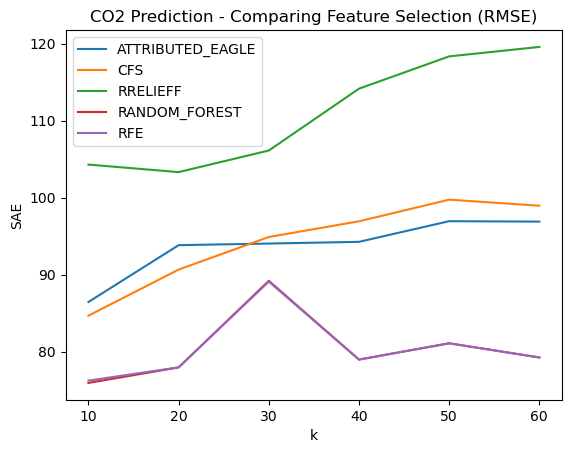

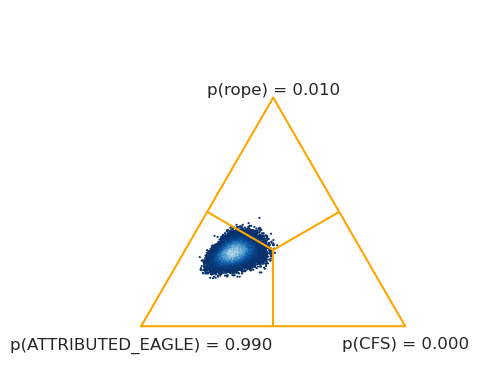

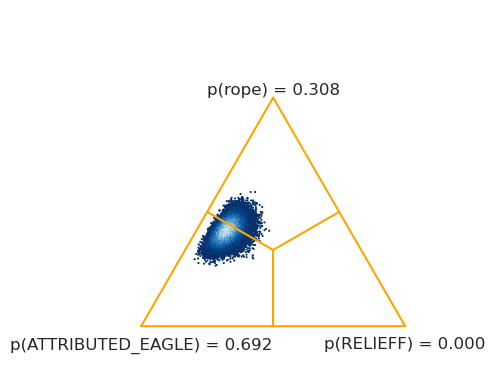

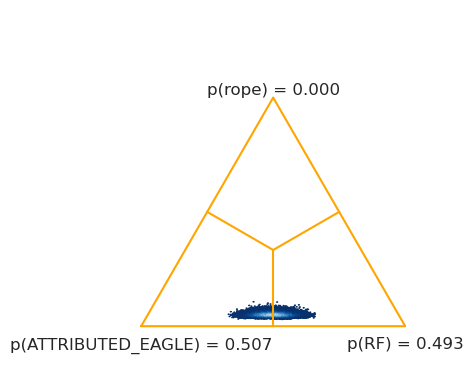

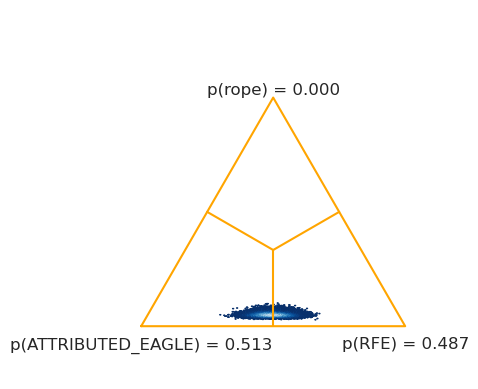

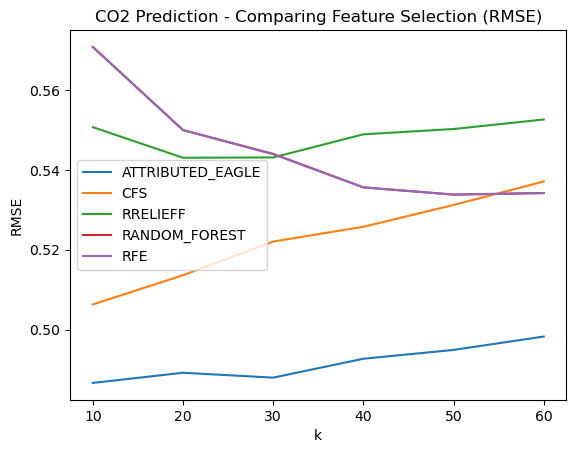

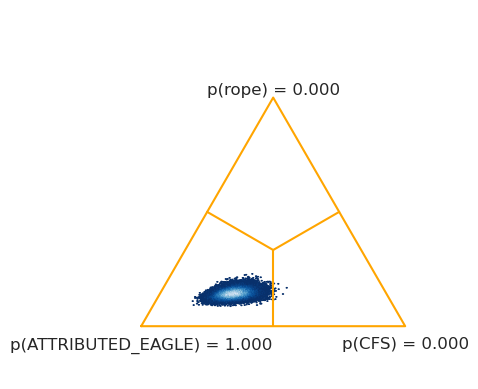

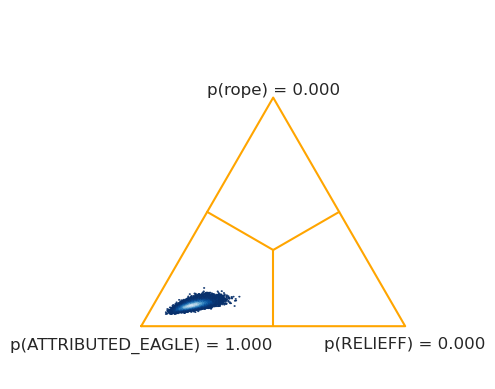

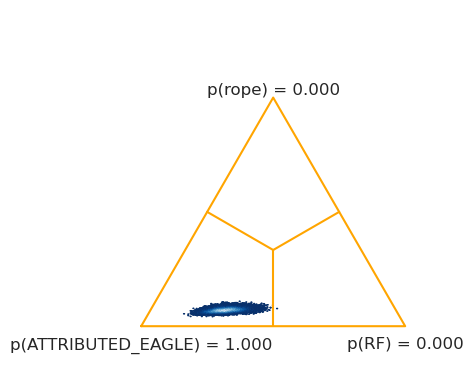

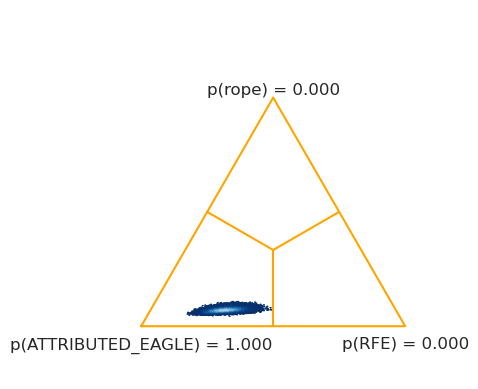

In [20]:
for measure in ['sae', 'rmse']:
    tmp = pd.DataFrame({model:combinado[model].groupby('k')[measure].mean() for model in combinado.keys()})
    rope = tmp.std()
    tmp.columns = ["ATTRIBUTED_EAGLE", "CFS",  "RRELIEFF","RANDOM_FOREST", "RFE"]
    plot = tmp.plot(kind='line',title = "CO2 Prediction - Comparing Feature Selection (RMSE)", ylabel=measure.upper())
    fig = plot.get_figure()
    fig.savefig("co2_"+measure+".pdf")
    for k, v in methods.items():
        fig = SignedRankTest.plot(-combinado['attributed_eagle_log_co2_n2.csv'][measure],
                                  -combinado[k][measure],rope=rope.mean(),names=["ATTRIBUTED_EAGLE",v])
        fig.savefig("co2_eagle_"+v.lower()+"_"+measure+".pdf")